## Question 2 : Social Network Analysis with the Facebook100 Dataset


--- Analyse de Caltech ---
Densité: 0.0574
Clustering global: 0.2913
Clustering local moyen: 0.4091


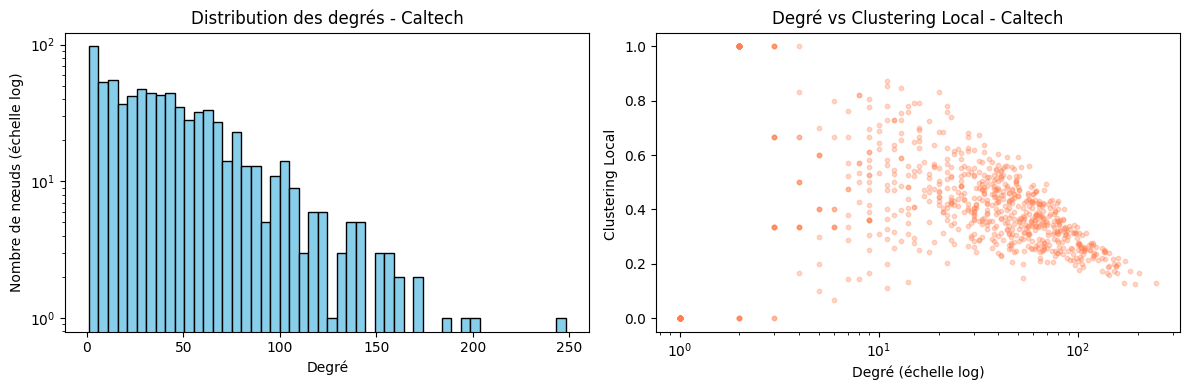


--- Analyse de MIT ---
Densité: 0.0123
Clustering global: 0.1803
Clustering local moyen: 0.2724


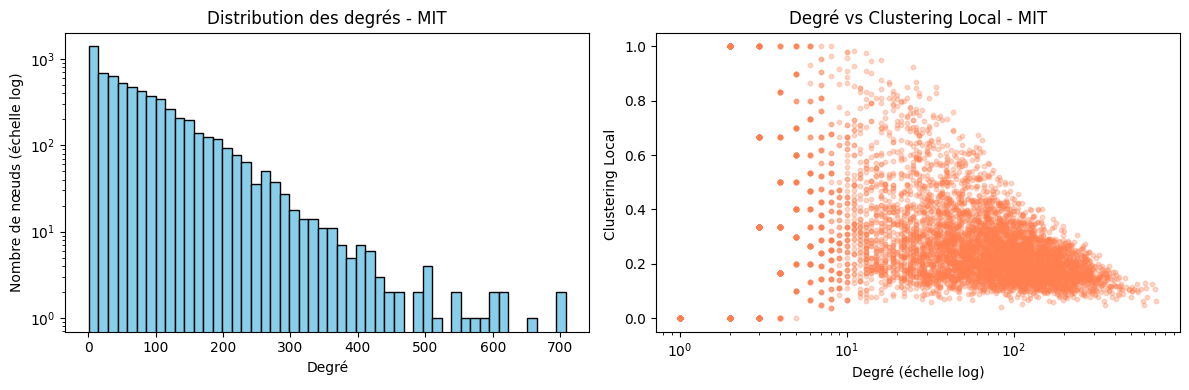


--- Analyse de Johns Hopkins ---
Densité: 0.0140
Clustering global: 0.1932
Clustering local moyen: 0.2690


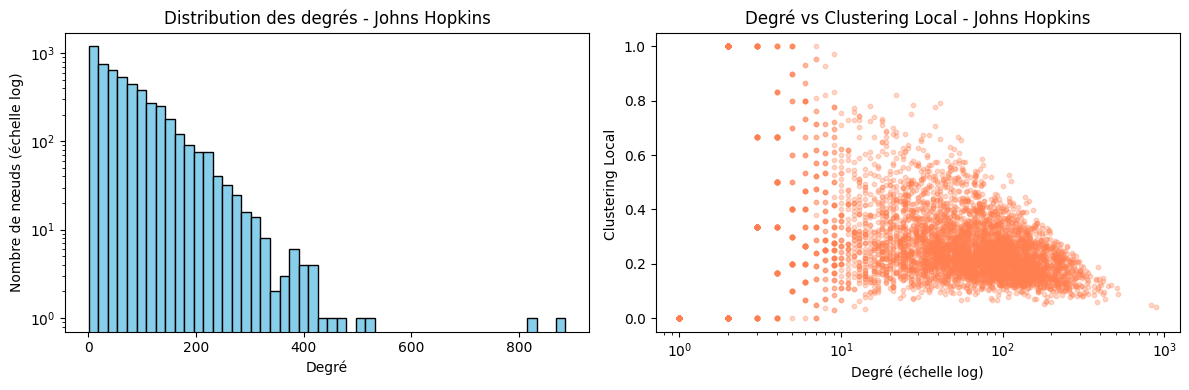

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Charger les données 
graphes = {
    "Caltech": nx.read_gml("data/Caltech36.gml"),
    "MIT": nx.read_gml("data/MIT8.gml"),
    "Johns Hopkins": nx.read_gml("data/JohnsHopkins55.gml")
}

for nom, G in graphes.items():
    composantes = nx.connected_components(G)
    lcc_nodes = max(composantes, key=len)
    G = G.subgraph(lcc_nodes)
    print(f"\n--- Analyse de {nom} ---")
    
    # a) Calculs
    densite = nx.density(G)
    clustering_global = nx.transitivity(G)
    clustering_local_moyen = nx.average_clustering(G)
    
    print(f"Densité: {densite:.4f}")
    print(f"Clustering global: {clustering_global:.4f}")
    print(f"Clustering local moyen: {clustering_local_moyen:.4f}")
    
    # Distribution des degrés
    degres = [deg for node, deg in G.degree()]
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(degres, bins=50, color='skyblue', edgecolor='black', log=True)
    plt.title(f"Distribution des degrés - {nom}")
    plt.xlabel("Degré")
    plt.ylabel("Nombre de nœuds (échelle log)")
    
    # b) Scatter plot Degré vs Clustering Local
    clustering_local = nx.clustering(G)
    plt.subplot(1, 2, 2)
    plt.scatter(degres, list(clustering_local.values()), alpha=0.3, s=10, color='coral')
    plt.xscale('log')
    plt.title(f"Degré vs Clustering Local - {nom}")
    plt.xlabel("Degré (échelle log)")
    plt.ylabel("Clustering Local ")
    
    plt.tight_layout()
    plt.show()

## Question 3 : Assortativity Analysis with the Facebook100 Dataset

Progression : 10 / 100 graphes traités...
Progression : 20 / 100 graphes traités...
Progression : 30 / 100 graphes traités...
Progression : 40 / 100 graphes traités...
Progression : 50 / 100 graphes traités...
Progression : 60 / 100 graphes traités...
Progression : 70 / 100 graphes traités...
Progression : 80 / 100 graphes traités...
Progression : 90 / 100 graphes traités...
Progression : 100 / 100 graphes traités...

Génération des graphiques...


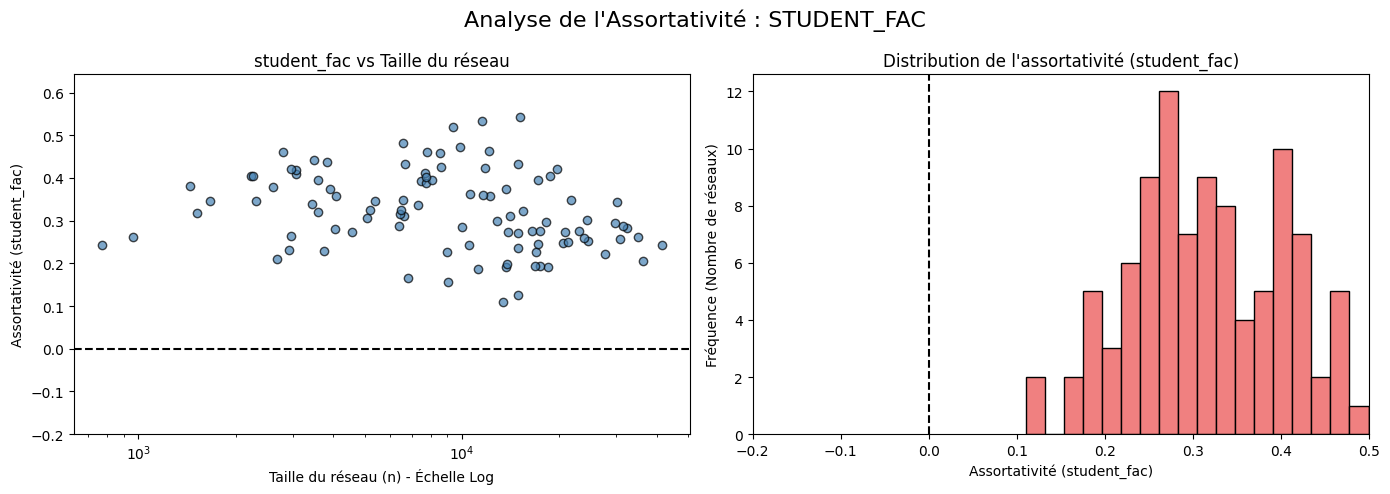

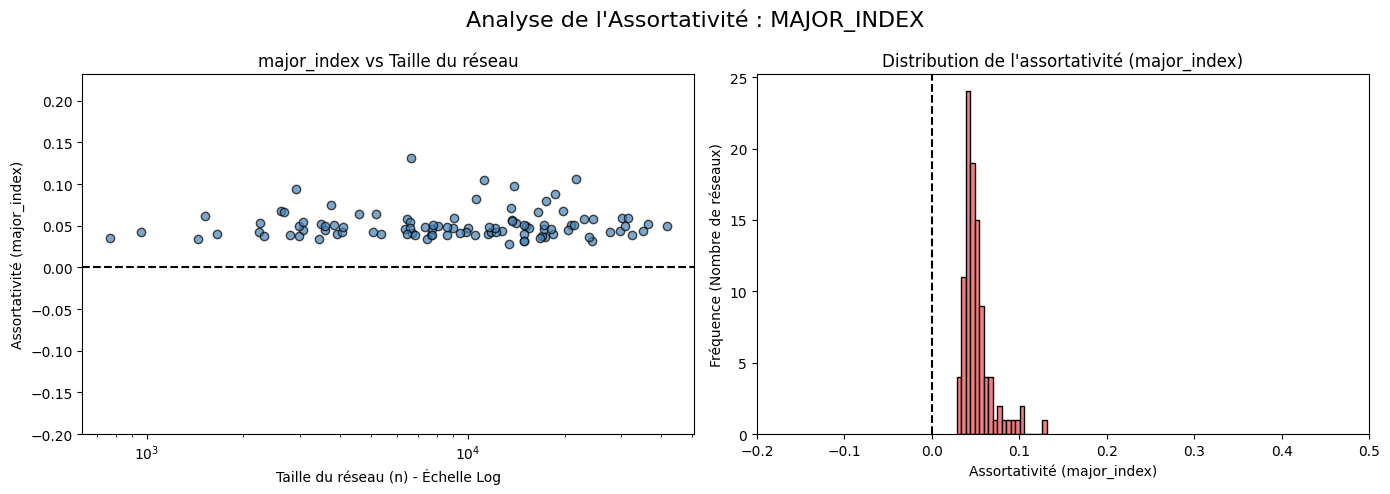

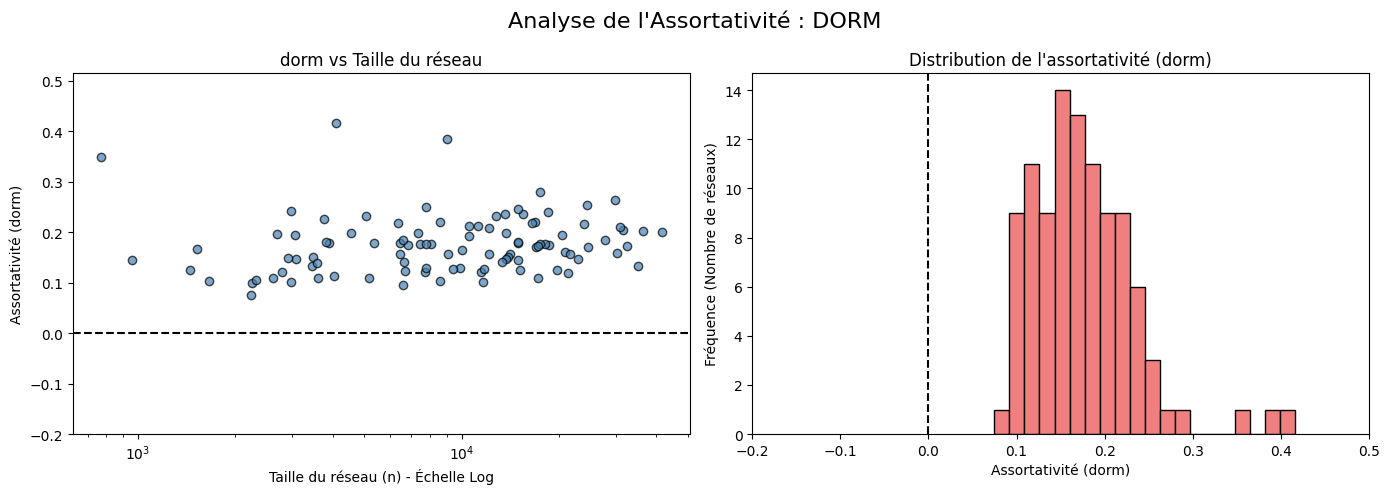

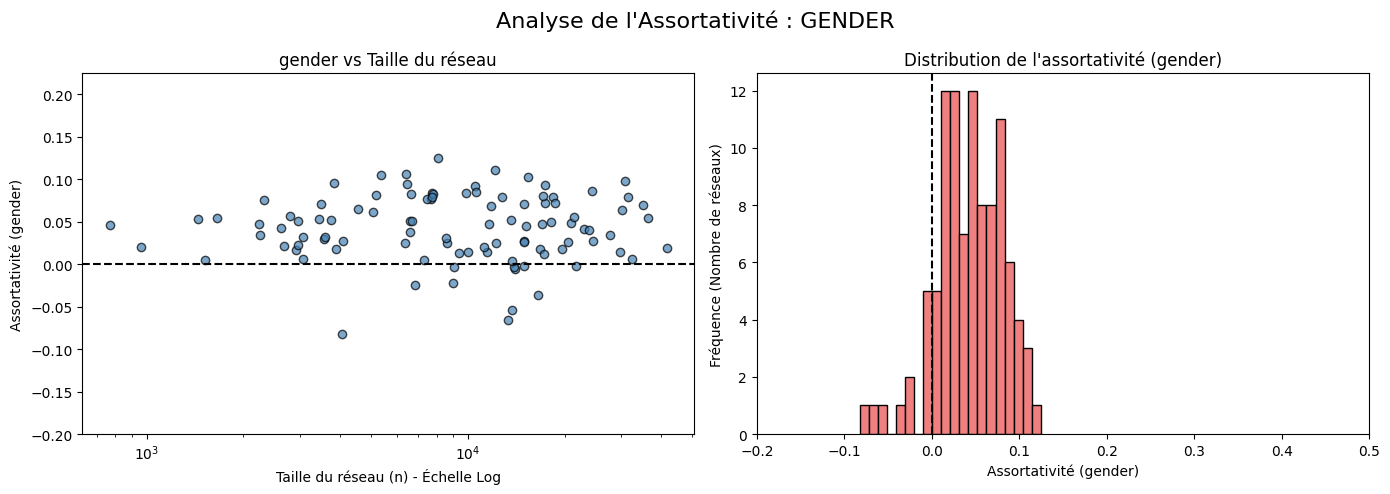

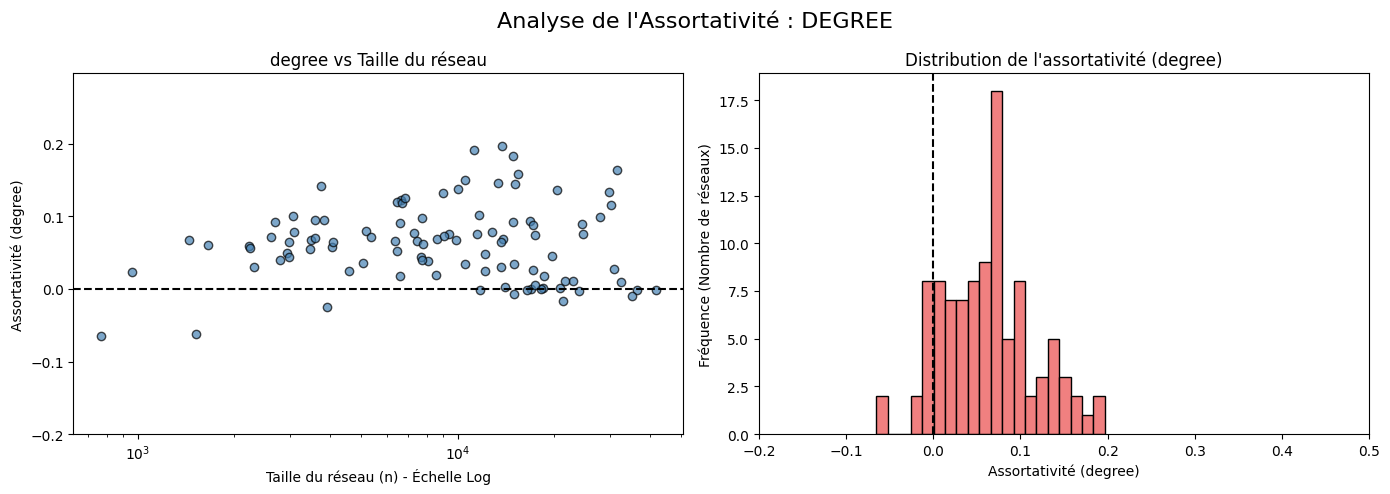

In [ ]:
import os
import networkx as nx
import matplotlib.pyplot as plt

dossier_data = "data" 

attributs = ["student_fac", "major_index", "dorm", "gender", "degree"]

resultats_assortativite = {attr: [] for attr in attributs}
tailles_reseaux = []

fichiers_gml = [f for f in os.listdir(dossier_data) if f.endswith('.gml')]

# Boucle sur les 100 graphes
for index, fichier in enumerate(fichiers_gml):
    chemin_fichier = os.path.join(dossier_data, fichier)
    G = nx.read_gml(chemin_fichier)
    
    # 1. Enregistrer la taille du réseau (n)
    n = G.number_of_nodes()
    tailles_reseaux.append(n)
    
    # 2. Nettoyage des données : attribuer 0 si un attribut est manquant pour un nœud
    for node, data in G.nodes(data=True):
        for attr in attributs:
            if attr != "degree" and attr not in data:
                data[attr] = 0
                
    # 3. Calculs des assortativités
    for attr in attributs:
        try:
            if attr == "degree":
                r = nx.degree_assortativity_coefficient(G)
            else:
                r = nx.attribute_assortativity_coefficient(G, attr)
            resultats_assortativite[attr].append(r)
        except Exception as e:
            import numpy as np
            resultats_assortativite[attr].append(np.nan)
            
    # Affichage de la progression tous les 10 graphes
    if (index + 1) % 10 == 0:
        print(f"Progression : {index + 1} / {len(fichiers_gml)} graphes traités...")

print("\n Génération des graphiques...")

# Génération graphs
for attr in attributs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Analyse de l'Assortativité : {attr.upper()}", fontsize=16)
    
    donnees_y = resultats_assortativite[attr]
    
    # 1. Scatter Plot (Assortativité vs Taille du réseau)
    ax1 = axes[0]
    ax1.scatter(tailles_reseaux, donnees_y, alpha=0.7, color='steelblue', edgecolors='black')
    ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax1.set_xscale('log') # Axes log-linéaires demandés
    ax1.set_xlabel('Taille du réseau (n) - Échelle Log')
    ax1.set_ylabel(f'Assortativité ({attr})')
    ax1.set_title(f'{attr} vs Taille du réseau')
    ax1.set_ylim([-0.2, max(donnees_y) + 0.1 if max(donnees_y) == max(donnees_y) else 0.5])
    
    # 2. Histogramme (Distribution des valeurs)
    ax2 = axes[1]
    donnees_propres = [val for val in donnees_y if str(val) != 'nan']
    ax2.hist(donnees_propres, bins=20, color='lightcoral', edgecolor='black')
    ax2.axvline(0, color='black', linestyle='--', linewidth=1.5) 
    ax2.set_xlabel(f'Assortativité ({attr})')
    ax2.set_ylabel('Fréquence (Nombre de réseaux)')
    ax2.set_title(f'Distribution de l\'assortativité ({attr})')
    ax2.set_xlim([-0.2, 0.5]) 
    
    plt.tight_layout()
    plt.show()

## Question 4 : Link Prediction

In [1]:
import networkx as nx
import random
import math
from abc import ABC, abstractmethod

G = nx.read_gml("data/Caltech36.gml")
G_lcc = G.subgraph(max(nx.connected_components(G), key=len))


#PARTIE 4(b) : LES CLASSES DE PRÉDICTION 
class LinkPrediction(ABC):
    def __init__(self, graph):
        self.graph = graph
        self.N = len(graph)
        
    def neighbors(self, v):
        return list(self.graph.neighbors(v))
        
    @abstractmethod
    def fit(self, u, v):
        raise NotImplementedError("Fit must be implemented")

class CommonNeighbors(LinkPrediction):
    def fit(self, u, v):
        return len(set(self.neighbors(u)).intersection(set(self.neighbors(v))))

class Jaccard(LinkPrediction):
    def fit(self, u, v):
        nu = set(self.neighbors(u))
        nv = set(self.neighbors(v))
        union_size = len(nu.union(nv))
        if union_size == 0: return 0
        return len(nu.intersection(nv)) / union_size

class AdamicAdar(LinkPrediction):
    def fit(self, u, v):
        common = set(self.neighbors(u)).intersection(set(self.neighbors(v)))
        return sum(1.0 / math.log(self.graph.degree(w)) for w in common if self.graph.degree(w) > 1)


# PARTIE 4(c) : LE PIPELINE D'ÉVALUATION 
def evaluate_predictor(G, predictor_class, f=0.1, k_values=[50, 100, 200, 300, 400]):
    print(f"Évaluation de {predictor_class.__name__} (fraction retirée f={f})...")
    
    # Étape 1 & 2 : Retirer une fraction f d'arêtes aléatoirement
    edges = list(G.edges())
    num_to_remove = int(f * len(edges))
    edges_removed = set(random.sample(edges, num_to_remove))
    
    # Création du graphe d'entraînement (sans les arêtes retirées)
    G_train = G.copy()
    G_train.remove_edges_from(edges_removed)
    
    # Étape 3 : Calculer le score pour toutes les paires de nœuds non connectées dans G_train
    predictor = predictor_class(G_train)
    predictions = []
    
    for u, v in nx.non_edges(G_train):
        score = predictor.fit(u, v)
        if score > 0: 
            predictions.append((score, frozenset([u, v])))
            
    # Étape 4 : Trier par ordre décroissant de confiance
    predictions.sort(key=lambda x: x[0], reverse=True)
    
    
    E_removed_set = set(frozenset([u, v]) for u, v in edges_removed)
    
    results = {}
    # Étape 5 : Calcul des métriques pour chaque k
    for k in k_values:
        
        top_k_preds = set(pair for score, pair in predictions[:k])
        
        
        TP = len(E_removed_set.intersection(top_k_preds))
        FP = k - TP
        FN = len(E_removed_set) - TP
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        results[k] = {'Precision': precision, 'Recall': recall}
        
    return results

# PARTIE 4(d) : EXÉCUTION 
predictors = [CommonNeighbors, Jaccard, AdamicAdar]

for pred in predictors:
    res = evaluate_predictor(G_lcc, pred, f=0.1)
    print(f"Résultats pour {pred.__name__}:")
    for k, metrics in res.items():
        print(f"  k={k} -> Precision: {metrics['Precision']:.4f} | Recall: {metrics['Recall']:.4f}")
    print("-" * 30)

Évaluation de CommonNeighbors (fraction retirée f=0.1)...
Résultats pour CommonNeighbors:
  k=50 -> Precision: 0.6200 | Recall: 0.0186
  k=100 -> Precision: 0.6000 | Recall: 0.0360
  k=200 -> Precision: 0.5850 | Recall: 0.0703
  k=300 -> Precision: 0.5000 | Recall: 0.0901
  k=400 -> Precision: 0.4600 | Recall: 0.1105
------------------------------
Évaluation de Jaccard (fraction retirée f=0.1)...
Résultats pour Jaccard:
  k=50 -> Precision: 0.4400 | Recall: 0.0132
  k=100 -> Precision: 0.4100 | Recall: 0.0246
  k=200 -> Precision: 0.3650 | Recall: 0.0438
  k=300 -> Precision: 0.3733 | Recall: 0.0673
  k=400 -> Precision: 0.3875 | Recall: 0.0931
------------------------------
Évaluation de AdamicAdar (fraction retirée f=0.1)...
Résultats pour AdamicAdar:
  k=50 -> Precision: 0.6800 | Recall: 0.0204
  k=100 -> Precision: 0.6400 | Recall: 0.0384
  k=200 -> Precision: 0.5600 | Recall: 0.0673
  k=300 -> Precision: 0.4900 | Recall: 0.0883
  k=400 -> Precision: 0.4500 | Recall: 0.1081
-------

In [11]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling
import networkx as nx
import random
from sklearn.preprocessing import StandardScaler

# 1. def modele gnn
class GNNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

# 2. fonction d'eval pour un graphe
def evaluate_gnn_on_graph(filepath):
    nom_fac = os.path.basename(filepath).replace('.gml', '')
    print(f"\n{'='*40}")
    print(f"Analyse en cours : {nom_fac}")
    print(f"{'='*40}")
 
    G = nx.read_gml(filepath)
    G_lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    features = []
    for node, d in G_lcc.nodes(data=True):
        features.append([
            d.get('dorm', 0),
            d.get('major_index', 0),
            d.get('year', 0),
            d.get('gender', 0)
        ])
    
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    x = torch.tensor(features_scaled, dtype=torch.float)

    f_remove = 0.1
    edges = list(G_lcc.edges())
    num_to_remove = int(f_remove * len(edges))
    edges_removed = set(random.sample(edges, num_to_remove))

    G_train = G_lcc.copy()
    G_train.remove_edges_from(edges_removed)

    mapping = {n: i for i, n in enumerate(G_train.nodes())}
    train_edges = [(mapping[u], mapping[v]) for u, v in G_train.edges()]
    edge_index = torch.tensor(train_edges, dtype=torch.long).t().contiguous()
    edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1) 

    data = Data(x=x, edge_index=edge_index)

    model = GNNLinkPredictor(in_channels=x.shape[1], hidden_channels=64, out_channels=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.BCEWithLogitsLoss()

    model.train()
    for epoch in range(100): 
        optimizer.zero_grad()
        z = model.encode(data.x, data.edge_index)
        
        neg_edge_index = negative_sampling(
            edge_index=data.edge_index, num_nodes=data.num_nodes,
            num_neg_samples=data.edge_index.size(1), method='sparse')
        
        edge_label_index = torch.cat([data.edge_index, neg_edge_index], dim=-1)
        edge_label = torch.cat([torch.ones(data.edge_index.size(1)), torch.zeros(neg_edge_index.size(1))], dim=0)
        
        out = model.decode(z, edge_label_index)
        loss = criterion(out, edge_label)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        z = model.encode(data.x, data.edge_index)
        non_edges = list(nx.non_edges(G_train))
        non_edges_idx = torch.tensor([[mapping[u], mapping[v]] for u, v in non_edges], dtype=torch.long).t()
        scores = model.decode(z, non_edges_idx).numpy()

    predictions = list(zip(scores, [frozenset([u, v]) for u, v in non_edges]))
    predictions.sort(key=lambda x: x[0], reverse=True)

    E_removed_set = set(frozenset([u, v]) for u, v in edges_removed)

    k_values = [50, 100, 200, 300, 400]
    for k in k_values:
        top_k_preds = set(pair for score, pair in predictions[:k])
        TP = len(E_removed_set.intersection(top_k_preds))
        FP = k - TP
        FN = len(E_removed_set) - TP
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        print(f"  k={k:<3} -> Precision: {precision:.4f} | Recall: {recall:.4f}")

# 3. boucle sur les 10 graphes les plus petits
dossier_data = "data"
tous_fichiers = [f for f in os.listdir(dossier_data) if f.endswith('.gml')]

print("Tri instantané des 10 plus petits graphes")

tailles_fichiers = []
for fichier in tous_fichiers:
    chemin_complet = os.path.join(dossier_data, fichier)
 
    poids_ko = os.path.getsize(chemin_complet) / 1024 
    tailles_fichiers.append((fichier, poids_ko))

tailles_fichiers.sort(key=lambda x: x[1])


fichiers_gml_selectionnes = [item[0] for item in tailles_fichiers[:10]]

print("\nLes 10 graphes les plus légers ont été trouvés :")
for f, poids in tailles_fichiers[:10]:
    print(f" - {f} : {poids:.0f} Ko")

# 4-execution sur les 10 choisis
print(f"\n{'='*40}")
print("Début de l'entraînement GNN sur ces 10 graphes")
for fichier in fichiers_gml_selectionnes:
    chemin_complet = os.path.join(dossier_data, fichier)
    evaluate_gnn_on_graph(chemin_complet)





Tri instantané des 10 plus petits graphes

Les 10 graphes les plus légers ont été trouvés :
 - Caltech36.gml : 813 Ko
 - Reed98.gml : 933 Ko
 - Simmons81.gml : 1635 Ko
 - Haverford76.gml : 2752 Ko
 - Swarthmore42.gml : 2859 Ko
 - USFCA72.gml : 3229 Ko
 - Bowdoin47.gml : 3977 Ko
 - Mich67.gml : 4131 Ko
 - Amherst41.gml : 4256 Ko
 - Oberlin44.gml : 4336 Ko

Début de l'entraînement GNN sur ces 10 graphes

Analyse en cours : Caltech36
  k=50  -> Precision: 0.0200 | Recall: 0.0006
  k=100 -> Precision: 0.0500 | Recall: 0.0030
  k=200 -> Precision: 0.0550 | Recall: 0.0066
  k=300 -> Precision: 0.0600 | Recall: 0.0108
  k=400 -> Precision: 0.0500 | Recall: 0.0120

Analyse en cours : Reed98
  k=50  -> Precision: 0.0000 | Recall: 0.0000
  k=100 -> Precision: 0.0200 | Recall: 0.0011
  k=200 -> Precision: 0.0450 | Recall: 0.0048
  k=300 -> Precision: 0.0533 | Recall: 0.0085
  k=400 -> Precision: 0.0575 | Recall: 0.0122

Analyse en cours : Simmons81
  k=50  -> Precision: 0.2000 | Recall: 0.0030
  

## Question 5: Find missing labels with the label propagation algorithms

In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import random

# 1. Définition du modèle GCN 
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# 2. Préparation des données 
def prepare_graph_data(G, target_attribute):
    """Convertit le graphe NetworkX en format PyTorch Geometric pour un attribut donné."""
    valid_nodes = [n for n, d in G.nodes(data=True) if target_attribute in d and d[target_attribute] != 0]
    G_sub = G.subgraph(valid_nodes)
    
    labels_raw = [G_sub.nodes[n][target_attribute] for n in G_sub.nodes()]
    unique_labels = list(set(labels_raw))
    label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
    
    y = torch.tensor([label_mapping[l] for l in labels_raw], dtype=torch.long)
    num_classes = len(unique_labels)
    num_nodes = G_sub.number_of_nodes()
    
    mapping_nodes = {n: i for i, n in enumerate(G_sub.nodes())}
    edges = [(mapping_nodes[u], mapping_nodes[v]) for u, v in G_sub.edges()]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1)
    
    x = torch.eye(num_nodes, dtype=torch.float)
    
    data = Data(x=x, edge_index=edge_index, y=y)
    return data, num_classes

# 3. Fonctions d'entrairement et eval
def train_and_evaluate(data, num_classes, fraction_removed):
    num_nodes = data.num_nodes
    indices = list(range(num_nodes))
    random.shuffle(indices)
    
    test_size = int(fraction_removed * num_nodes)
    test_indices = indices[:test_size]
    train_indices = indices[test_size:]
    
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_indices] = True
    test_mask[test_indices] = True
    
    # Initialisation du modèle GCN
    model = GCN(num_features=data.num_features, hidden_channels=16, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    # Entraînement
    model.train()
    for epoch in range(200): 
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.nll_loss(out[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()
        
    # Évaluation sur les nœuds "supprimés" 
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        
        correct = (pred[test_mask] == data.y[test_mask]).sum().item()
        accuracy = correct / test_mask.sum().item()
        
        mae = torch.abs(pred[test_mask] - data.y[test_mask]).float().mean().item()
        
    return accuracy, mae

# 4. Execution de l'experience
G = nx.read_gml("data/Caltech36.gml")
G_lcc = G.subgraph(max(nx.connected_components(G), key=len))

attributs_a_tester = ["dorm", "major_index", "gender"]
fractions = [0.1, 0.2, 0.3]

print(f"{'Attribut':<15} | {'Fraction retirée':<15} | {'Accuracy':<10} | {'MAE':<10}")
print("-" * 55)

for attr in attributs_a_tester:
    if attr in list(G_lcc.nodes(data=True))[0][1]:
        data, num_classes = prepare_graph_data(G_lcc, attr)
        for f in fractions:
            acc, mae = train_and_evaluate(data, num_classes, f)
            print(f"{attr:<15} | {f:<15} | {acc:.4f}     | {mae:.4f}")
    else:
        print(f"L'attribut {attr} n'est pas présent dans ce graphe.")

Attribut        | Fraction retirée | Accuracy   | MAE       
-------------------------------------------------------
dorm            | 0.1             | 0.8475     | 0.4068
dorm            | 0.2             | 0.8644     | 0.3305
dorm            | 0.3             | 0.8315     | 0.5449
major_index     | 0.1             | 0.2353     | 8.6912
major_index     | 0.2             | 0.1168     | 10.1022
major_index     | 0.3             | 0.1845     | 8.8592
gender          | 0.1             | 0.7101     | 0.2899
gender          | 0.2             | 0.6691     | 0.3309
gender          | 0.3             | 0.6746     | 0.3254


## Question 6 : Communities detection with the FB100 datasets

In [3]:
import networkx as nx
from networkx.algorithms.community import louvain_communities
from sklearn.metrics import normalized_mutual_info_score
import numpy as np
import os

# 1. Fonctions d'analyse de communautes 
def analyse_communautes(filepath):
    nom_fac = os.path.basename(filepath).replace('.gml', '')
    print(f"\n{'='*40}")
    print(f"Analyse de l'université : {nom_fac}")
    print(f"{'='*40}")
    
    G = nx.read_gml(filepath)
    LCC_nodes = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(LCC_nodes)
    
    # Detection avec Louvain
    communities = louvain_communities(G_lcc, seed=42)
    print(f"L'algorithme de Louvain a trouvé {len(communities)} communautés.")
    
    nodes_list = list(G_lcc.nodes())
    
    partition_louvain = {}
    for i, comm in enumerate(communities):
        for node in comm:
            partition_louvain[node] = i
            
    labels_louvain = [partition_louvain[n] for n in nodes_list]
    
    labels_dorm = [G_lcc.nodes[n].get('dorm', 0) for n in nodes_list]
    labels_year = [G_lcc.nodes[n].get('year', 0) for n in nodes_list]
    labels_major = [G_lcc.nodes[n].get('major_index', 0) for n in nodes_list]
    
    # Calcul scores NMI
    nmi_dorm = normalized_mutual_info_score(labels_dorm, labels_louvain)
    nmi_year = normalized_mutual_info_score(labels_year, labels_louvain)
    nmi_major = normalized_mutual_info_score(labels_major, labels_louvain)
    
    print("\nScore de correspondance (NMI) entre les communautés et la réalité :")
    print("-" * 60)
    print(f"Correspondance avec le Dortoir (Dorm)       : {nmi_dorm:.4f}")
    print(f"Correspondance avec l'Année (Year)          : {nmi_year:.4f}")
    print(f"Correspondance avec la Spécialité (Major)   : {nmi_major:.4f}")

# 2. Execution
chemins = [
    "data/Caltech36.gml",
    "data/MIT8.gml" 
]

for chemin in chemins:
    if os.path.exists(chemin):
        analyse_communautes(chemin)
    else:
        print(f"Fichier introuvable : {chemin}")


Analyse de l'université : Caltech36
L'algorithme de Louvain a trouvé 9 communautés.

Score de correspondance (NMI) entre les communautés et la réalité :
------------------------------------------------------------
Correspondance avec le Dortoir (Dorm)       : 0.5304
Correspondance avec l'Année (Year)          : 0.1001
Correspondance avec la Spécialité (Major)   : 0.0793

Analyse de l'université : MIT8
L'algorithme de Louvain a trouvé 12 communautés.

Score de correspondance (NMI) entre les communautés et la réalité :
------------------------------------------------------------
Correspondance avec le Dortoir (Dorm)       : 0.2550
Correspondance avec l'Année (Year)          : 0.2164
Correspondance avec la Spécialité (Major)   : 0.0393
